# HITO 2 – Análisis Exploratorio de Datos (EDA) y Preprocesamiento
## Desarrollo e Integración de Servicios de IA (DISIA)
### Proyecto: Detección de Intrusos en Sistemas IIoT (X-IIoTID)

---

### Índice del Cuaderno:
1. [Carga de Datos y Análisis Estructural Inicial](#1)
2. [Distribución de la Variable Objetivo (Desbalanceo de Clases)](#2)
3. [Limpieza de Datos (Pipeline Base)](#3)
4. [Análisis de Calidad y Tratamiento de Nulos](#4)
5. [Análisis de Multicolinealidad (Correlación)](#5)
6. [Análisis Estadístico y Distribuciones](#6)
7. [Formulación de Métricas Base (Baseline)](#7)
8. [Análisis de Separabilidad en 2D (PCA)](#8)
9. [Conclusiones del EDA y Preparación para el Hito 3](#9)

---

### 0. Importación de librerías

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
import warnings

# Configuración del entorno
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid", palette="muted")

print("Entorno configurado. Librerías importadas.")

Entorno configurado. Librerías importadas.


### 1. Carga de Datos y Análisis Estructural Inicial
Se realiza la carga del archivo CSV y se evalúa su dimensionalidad para confirmar que estamos ante un volumen de datos representativo de un entorno IIoT masivo.

In [19]:
path = "X-IIoTID dataset.csv"

try:
    df = pd.read_csv(path, low_memory=False)
    print(f"Datos cargados: {df.shape[0]:,} registros y {df.shape[1]} características.")
    display(df.head(3))
except FileNotFoundError:
    print("Error: No se ha encontrado el archivo CSV. Súbelo al entorno.")

Datos cargados: 820,834 registros y 68 características.


,Date,Timestamp,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,...,OSSEC_alert_level,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3
0,9/01/2020,1578540956,192.168.2.199,49278,192.168.2.10,80,tcp,http,0.67369,13437,...,5,0,0,0,0,0,0,Scanning_vulnerability,Reconnaissance,Attack
1,13/01/2020,1578871873,10.0.1.5,39769,131.236.3.92,53,udp,dns,0.000083,78,...,0,0,0,0,0,0,0,Normal,Normal,Normal
2,9/01/2020,1578522486,172.24.1.80,59050,172.24.1.1,53,udp,dns,0.000132,38,...,0,0,0,0,0,0,0,Normal,Normal,Normal


### 2. Distribución de la Variable Objetivo (Desbalanceo de Clases)
En problemas de ciberseguridad, el tráfico anómalo suele ser una minoría. Analizamos la etiqueta `class3` (Normal vs Attack) para determinar si será necesario aplicar técnicas de sobremuestreo (como SMOTE) durante el entrenamiento.

=== DISTRIBUCIÓN DE TRÁFICO ===
- Normal: 421,417 registros (51.34%)
- Attack: 399,417 registros (48.66%)


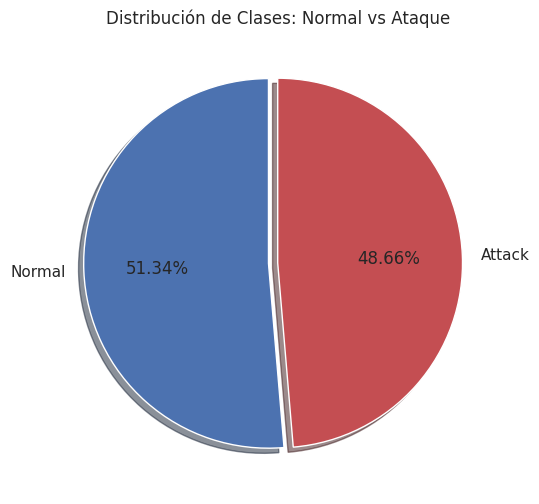

Interpretación: El dataset está casi perfectamente balanceado (51.3% vs 48.7%).
No será necesario aplicar técnicas agresivas de balanceo en fases posteriores.


In [20]:
conteo_clases = df['class3'].value_counts()
proporciones = df['class3'].value_counts(normalize=True) * 100

print("=== DISTRIBUCIÓN DE TRÁFICO ===")
for clase, cantidad in conteo_clases.items():
    print(f"- {clase.capitalize()}: {cantidad:,} registros ({proporciones[clase]:.2f}%)")

plt.figure(figsize=(6, 6))
plt.pie(conteo_clases, labels=conteo_clases.index.str.capitalize(), autopct='%1.2f%%',
        colors=['#4C72B0', '#C44E52'], startangle=90, explode=(0.05, 0), shadow=True)
plt.title('Distribución de Clases: Normal vs Ataque')
plt.show()

print("Interpretación: El dataset está casi perfectamente balanceado (51.3% vs 48.7%).")
print("No será necesario aplicar técnicas agresivas de balanceo en fases posteriores.")

### 3. Limpieza de Datos (Pipeline Base) <a name="3"></a>
El dataset original presenta inconsistencias de tipado: booleanos como cadenas de texto ('true'/'false'), valores numéricos casteados como `object`, y nulos representados mediante caracteres especiales ('-', '?').

Se aplican las funciones de estandarización con el fin de forzar un tipado estricto.

In [21]:
print("Aplicando pipeline de limpieza de datos...")

common_replacements = {'-': np.nan, '?': np.nan, 'nan': np.nan}

def replace_common_values(dataframe):
    for col in dataframe.select_dtypes(include=['object']).columns:
        dataframe[col] = dataframe[col].replace(common_replacements)
    return dataframe

def fix_mayus(dataframe):
    for col in dataframe.select_dtypes(include=['object']).columns:
        dataframe[col] = dataframe[col].str.lower()
    return dataframe

def fix_dtype(dataframe, umbral_numerico=0.7):
    object_cols = dataframe.select_dtypes(include=['object']).columns
    int_cols = dataframe.select_dtypes(include=['int64']).columns
    bool_cols = dataframe.select_dtypes(include=['bool']).columns

    dataframe[bool_cols] = dataframe[bool_cols].astype(float)

    for col in object_cols:
        valores_unicos = dataframe[col].dropna().unique()
        if {"true", "false"} <= set(valores_unicos):
            dataframe[col] = dataframe[col].map({'true': 1.0, 'false': 0.0}).astype(float)
        else:
            converted = pd.to_numeric(dataframe[col], errors='coerce')
            if converted.notna().mean() > umbral_numerico:
                dataframe[col] = converted.astype(float)

    for col in int_cols:
        dataframe[col] = dataframe[col].astype(float)
    return dataframe

df_clean = replace_common_values(df)
df_clean = fix_mayus(df_clean)
df_clean = fix_dtype(df_clean)

print("Tipos de datos corregidos. Estructura optimizada para el modelado matemático.")

Aplicando pipeline de limpieza de datos...
Tipos de datos corregidos. Estructura optimizada para el modelado matemático.


### 4. Análisis de Calidad y Tratamiento de Nulos <a name="4"></a>
Se identifica la proporción de valores perdidos (Missing Values). Para garantizar la integridad metodológica, dividimos el conjunto en `Train` y `Test` antes de imputar los nulos con medidas estadísticas (como la media), evitando así la contaminación cruzada de datos.

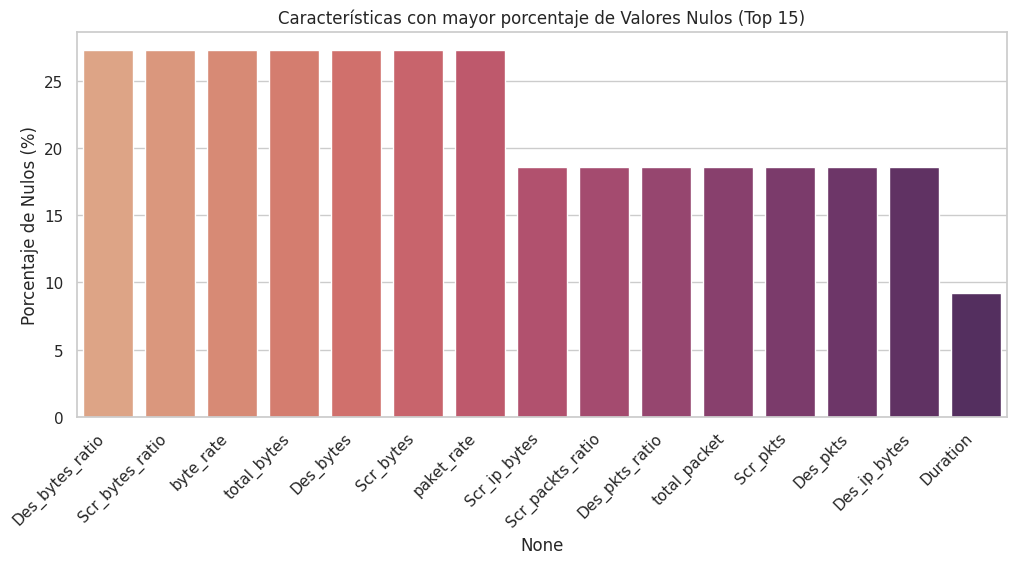

Particionado y validación de nulos completados. Registros en el conjunto de entrenamiento: 655,345.


In [22]:
nulos = df_clean.isnull().sum()
df_nulos = pd.DataFrame({'Cantidad': nulos, 'Porcentaje (%)': (nulos / len(df_clean)) * 100})
df_nulos = df_nulos[df_nulos['Cantidad'] > 0].sort_values(by='Cantidad', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=df_nulos.index[:15], y=df_nulos['Porcentaje (%)'][:15], palette='flare')
plt.xticks(rotation=45, ha='right')
plt.title('Características con mayor porcentaje de Valores Nulos (Top 15)')
plt.ylabel('Porcentaje de Nulos (%)')
plt.show()

# ESTRATEGIA DE IMPUTACIÓN
columnas_excepcion = [col for col in df_nulos.index[:15] if col in df_clean.columns]
no_borrar = [col for col in df_clean.columns if col not in columnas_excepcion]
df_final = df_clean.dropna(subset=no_borrar) # Eliminamos nulos residuales

# Transformamos la etiqueta a binario
y = df_final['class3'].apply(lambda x: 0 if x == 'normal' else 1)
X = df_final.drop(columns=['class1', 'class2', 'class3', 'date', 'timestamp'], errors='ignore')

# Particionado Estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imputación (Ajustada SÓLO en Train)
imputer = SimpleImputer(strategy='mean')
X_train[columnas_excepcion] = imputer.fit_transform(X_train[columnas_excepcion])
X_test[columnas_excepcion] = imputer.transform(X_test[columnas_excepcion])

print(f"Particionado y validación de nulos completados. Registros en el conjunto de entrenamiento: {len(X_train):,}.")

### 5. Análisis de Multicolinealidad (Correlación) <a name="5"></a>
Calculamos la matriz de correlación de Pearson para extraer los pares de variables que transmiten información redundante (coeficiente > 0.8 o < -0.8). Esto justificará la futura selección de características o reducción de dimensionalidad (PCA).

In [23]:
numeric_df = X_train.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Extraemos la parte triangular superior para evitar pares duplicados
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.85)]

print(f"Se han detectado {len(to_drop)} variables altamente correlacionadas (|r| > 0.85).")
print("Ejemplo de variables redundantes que podrían eliminarse o combinarse:")
print(to_drop[:10])

# Visualizamos un subconjunto clave para no saturar el renderizado
subset_cols = ['duration', 'scr_bytes', 'des_bytes', 'paket_rate', 'avg_user_time', 'process_activity']
subset_cols = [c for c in subset_cols if c in X_train.columns]

if len(subset_cols) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(X_train[subset_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Matriz de Correlación (Subconjunto de métricas de Host/Red)')
    plt.show()

Se han detectado 21 variables altamente correlacionadas (|r| > 0.85).
Ejemplo de variables redundantes que podrían eliminarse o combinarse:
['is_pure_ack', 'FIN or RST', 'Scr_ip_bytes', 'Des_pkts', 'Des_ip_bytes', 'total_bytes', 'total_packet', 'byte_rate', 'Des_pkts_ratio', 'Des_bytes_ratio']


### 6. Análisis Estadístico y Distribuciones <a name="6"></a>
Comparamos las distribuciones de las variables de red en función de la clase (Normal vs Ataque). Dado que el tráfico de red suele tener una asimetría positiva extrema (long tail), utilizamos una representación en escala logarítmica.

=== DISTRIBUCIONES: NORMAL VS ATAQUE ===


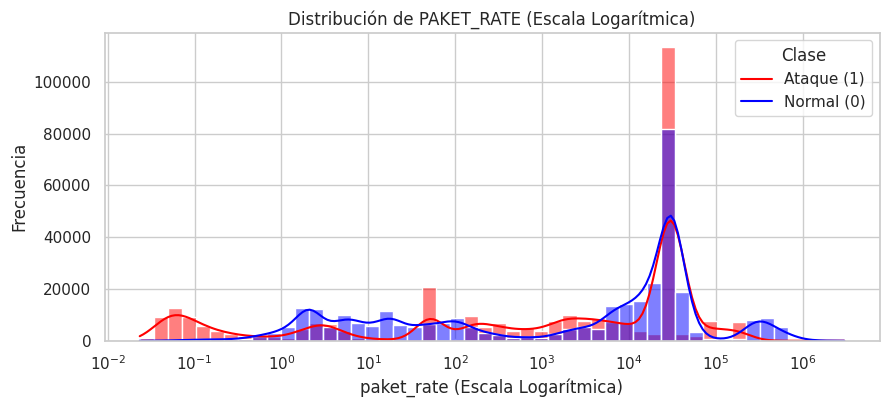

Interpretación: Observamos que ciertas métricas de red muestran un solapamiento significativo,
lo que evidencia que el uso de reglas estáticas no sería suficiente. Se requiere un modelo no lineal.


In [24]:
print("=== DISTRIBUCIONES: NORMAL VS ATAQUE ===")

# Reunimos X e y temporalmente para graficar
df_plot = X_train.copy()
df_plot['Target'] = y_train.values

for var in ['scr_bytes', 'paket_rate']:
    if var in df_plot.columns:
        plt.figure(figsize=(10, 4))
        sns.histplot(data=df_plot, x=var, hue='Target', bins=50,
                     log_scale=True, palette={0: 'blue', 1: 'red'}, alpha=0.5, kde=True)
        plt.title(f'Distribución de {var.upper()} (Escala Logarítmica)')
        plt.xlabel(f'{var} (Escala Logarítmica)')
        plt.ylabel('Frecuencia')
        plt.legend(title='Clase', labels=['Ataque (1)', 'Normal (0)'])
        plt.show()

print("Interpretación: Observamos que ciertas métricas de red muestran un solapamiento significativo,")
print("lo que evidencia que el uso de reglas estáticas no sería suficiente. Se requiere un modelo no lineal.")

### 7. Formulación de Métricas Base (Baseline) <a name="7"></a>
En ciberseguridad industrial, equivocarse tiene un coste asimétrico:
- Un Falso Negativo implica que un intruso vulnera el sistema (coste crítico).
- Un Falso Positivo satura de alertas innecesarias a los analistas (fatiga de alarmas y sobrecarga operativa).

Simulamos un clasificador aleatorio como línea base. Cualquier modelo de ML desarrollado en el Hito 3 deberá superar drásticamente estas métricas, maximizando el Recall y minimizando la tasa de falsos positivos (FPR).

In [25]:
print("=== EVALUACIÓN DE LÍNEA BASE (BASELINE) ===")

# Simulador aleatorio basado en la distribución de las clases
np.random.seed(42)
y_pred_baseline = np.random.choice([0, 1], size=len(y_test), p=[0.51, 0.49])

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_baseline).ravel()

recall = tp / (tp + fn)
fpr = fp / (fp + tn)
precision = tp / (tp + fp)

print(f"Total de eventos de prueba: {len(y_test):,}")
print("-" * 40)
print(f"RECALL (Tasa de detección): {recall:.4f}")
print(f"FPR (Tasa de falsas alarmas): {fpr:.4f}")
print(f"PRECISION: {precision:.4f}")
print("-" * 40)

print("\nConclusión:")
print("El modelo base aleatorio genera un FPR inaceptable en un entorno IIoT (clasifica la mitad del tráfico")
print("normal como un ataque). El objetivo de optimización en el Hito 3 consistirá en desarrollar algoritmos")
print("capaces de reducir el FPR por debajo del 5% manteniendo un Recall superior al 90%.")

=== EVALUACIÓN DE LÍNEA BASE (BASELINE) ===
Total de eventos de prueba: 163,837
----------------------------------------
RECALL (Tasa de detección): 0.4926
FPR (Tasa de falsas alarmas): 0.4890
PRECISION: 0.4883
----------------------------------------

Conclusión:
El modelo base aleatorio genera un FPR inaceptable en un entorno IIoT (clasifica la mitad del tráfico
normal como un ataque). El objetivo de optimización en el Hito 3 consistirá en desarrollar algoritmos
capaces de reducir el FPR por debajo del 5% manteniendo un Recall superior al 90%.


### 8. Análisis de Separabilidad en 2D (PCA) <a name="8"></a>
Reducimos la dimensionalidad del dataset a 2 componentes principales para visualizar si el tráfico anómalo es linealmente separable del tráfico normal en un espacio de baja dimensión. Esto justificará matemáticamente la elección de los futuros modelos.

=== VISUALIZACIÓN DE SEPARABILIDAD (PCA) ===


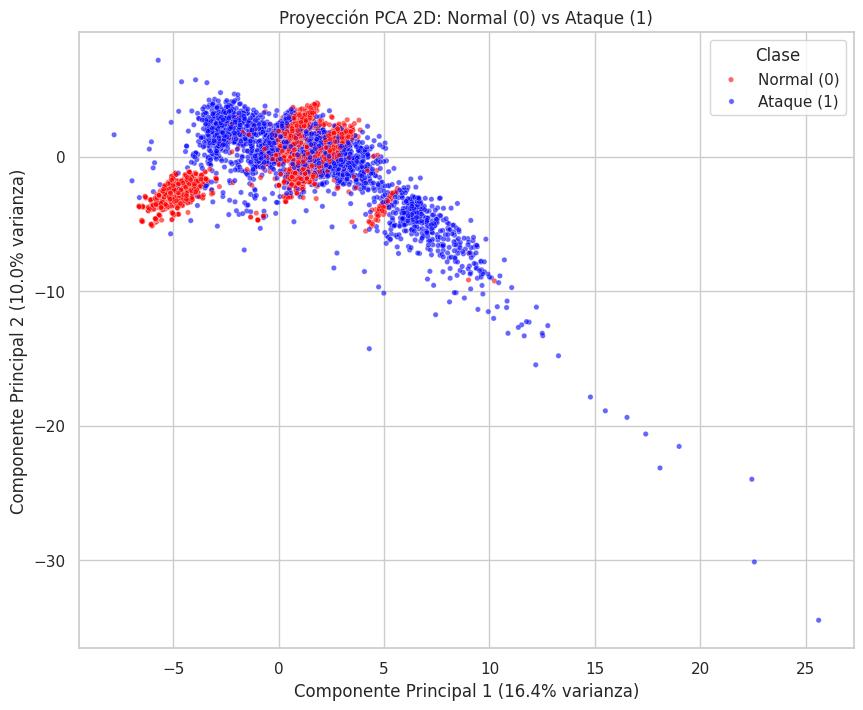

Interpretación: Como se observa en la gráfica, las clases Normal (azul) y Ataque (rojo)
están altamente solapadas, sin una frontera de separación lineal clara.
Esto significa que los ciberataques están diseñados para mimetizarse con el tráfico
legítimo. Por tanto, se justifica la necesidad de utilizar algoritmos de Machine
Learning complejos y no lineales (como Random Forest o Redes Neuronales) en el Hito 3.


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("=== VISUALIZACIÓN DE SEPARABILIDAD (PCA) ===")

# Escalamos los datos usando un subconjunto aleatorio para no saturar la memoria gráfica
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=10000, random_state=42, stratify=y_train)

# Filtramos para quedarnos estrictamente con las columnas numéricas
X_sample_numeric = X_sample.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample_numeric)

# Aplicamos PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Graficamos
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_sample, palette={0: 'blue', 1: 'red'}, alpha=0.6, s=15)
plt.title('Proyección PCA 2D: Normal (0) vs Ataque (1)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.legend(title='Clase', labels=['Normal (0)', 'Ataque (1)'])
plt.show()

print("Interpretación: Como se observa en la gráfica, las clases Normal (azul) y Ataque (rojo)")
print("están altamente solapadas, sin una frontera de separación lineal clara.")
print("Esto significa que los ciberataques están diseñados para mimetizarse con el tráfico")
print("legítimo. Por tanto, se justifica la necesidad de utilizar algoritmos de Machine")
print("Learning complejos y no lineales (como Random Forest o Redes Neuronales) en el Hito 3.")

### 9. Conclusiones del EDA y Preparación para el Hito 3 <a name="9"></a>

Tras el análisis exploratorio exhaustivo del conjunto de datos **X-IIoTID**, se extraen las siguientes conclusiones arquitectónicas para el diseño del sistema de detección:

1. **Viabilidad del Dataset:** El volumen de datos y el equilibrio de clases (~51% Normal / ~49% Ataque) conforman un escenario ideal para el aprendizaje automático sin necesidad de técnicas de generación de datos sintéticos.
2. **Calidad del Dato:** Se ha implementado un pipeline robusto que corrige errores de tipado nativos y gestiona valores nulos mediante imputación estadística, asegurando que no exista fuga de información (*Data Leakage*) al particionar previamente en *Train/Test*.
3. **Complejidad del Problema:** El análisis de distribuciones, la multicolinealidad y la proyección PCA demuestran que el tráfico malicioso imita patrones legítimos. Un enfoque basado en reglas estáticas o umbrales simples fracasaría (como demostró el alto FPR del modelo *Baseline*).
4. **Siguientes pasos (Hito 3):** Los datos preprocesados en este cuaderno servirán como entrada directa para la fase de modelado. Se priorizará el entrenamiento de modelos capaces de capturar relaciones no lineales, con el objetivo de maximizar la Tasa de Detección (*Recall*) y mantener la Tasa de Falsas Alarmas (*FPR*) cerca del 0%, garantizando así la operatividad real en un entorno industrial.